# Transformer-based Localization Training

이 노트북은 TOA 위치 데이터를 시퀀스로 처리하여 실제 위치를 예측하는 트랜스포머 모델을 학습합니다.

## 데이터 구조
- `toaPos`: (5, 10, 100000, 2) → (noise_variance, points, samples, coordinates)
- `realPos`: (5, 10, 100000, 2)
- 각 noise variance별로 데이터를 분리
- 10개 points를 시퀀스로 처리 (seq_len=10)
- 각 point는 2D 좌표

In [1]:
# 필수 라이브러리 import
import sys
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
from tqdm import tqdm
import math

# 경로 설정
sys.path.insert(0, os.path.abspath('.'))
print(f"Current working directory: {os.getcwd()}")

# 디바이스 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Current working directory: c:\Users\myhom\codebase\localization-filters-2d\pytorch
Using device: cuda


In [2]:
# HDF5에서 데이터 로드
from load_h5_data import load_h5_simulation_data

print("Loading data from HDF5...")
data = load_h5_simulation_data('../data/simulation_data.h5')

toaPos = data['toaPos']  # (5, 10, 100000, 2)
realPos = data['realPos']  # (5, 10, 100000, 2)

print(f"\ntoaPos shape: {toaPos.shape}")
print(f"realPos shape: {realPos.shape}")
print(f"\nShape interpretation:")
print(f"  Dimension 0: {toaPos.shape[0]} noise variance levels")
print(f"  Dimension 1: {toaPos.shape[1]} points (sequence length)")
print(f"  Dimension 2: {toaPos.shape[2]} samples")
print(f"  Dimension 3: {toaPos.shape[3]} coordinates (x, y)")

Loading data from HDF5...
HDF5 File Structure (showing datasets):
--------------------------------------------------
  Dataset: realPos, Shape: (5, 10, 100000, 2), dtype: float64
  Dataset: toaPos, Shape: (5, 10, 100000, 2), dtype: float64
--------------------------------------------------
Loaded 'toaPos': shape (5, 10, 100000, 2)
Loaded 'realPos': shape (5, 10, 100000, 2)

toaPos shape: (5, 10, 100000, 2)
realPos shape: (5, 10, 100000, 2)

Shape interpretation:
  Dimension 0: 5 noise variance levels
  Dimension 1: 10 points (sequence length)
  Dimension 2: 100000 samples
  Dimension 3: 2 coordinates (x, y)


In [3]:
# 시퀀스 기반 데이터셋 클래스
class SequenceLocalizationDataset(Dataset):
    """
    시퀀스 형태로 TOA 위치를 처리하는 데이터셋
    """
    def __init__(self, toaPos, realPos, noise_idx=None, device='cpu'):
        """
        Parameters:
        -----------
        toaPos : ndarray
            shape (N, P, S, 2) where N=noise_variance, P=points, S=samples, C=coordinates
        realPos : ndarray
            shape (N, P, S, 2)
        noise_idx : int or None
            특정 noise variance level을 선택 (None이면 모든 레벨 사용)
        device : str
            'cpu' 또는 'cuda'
        """
        if noise_idx is not None:
            # 특정 noise variance만 선택: (N, P, S, 2) -> (P, S, 2)
            if toaPos.ndim == 4:
                toaPos = toaPos[noise_idx]  # (P, S, 2)
                realPos = realPos[noise_idx]
                
                # (P, S, 2) -> (S, P, 2): samples x points x coords
                P, S, C = toaPos.shape
                toaPos = toaPos.transpose(1, 0, 2)  # (S, P, 2)
                realPos = realPos.transpose(1, 0, 2)
            self.noise_idx = noise_idx
        else:
            # 모든 noise variance를 평탄화: (N, P, S, 2) -> (N*S, P, 2)
            if toaPos.ndim == 4:
                N, P, S, C = toaPos.shape
                toaPos = toaPos.transpose(0, 2, 1, 3).reshape(N*S, P, C)  # (N*S, P, 2)
                realPos = realPos.transpose(0, 2, 1, 3).reshape(N*S, P, C)
            self.noise_idx = None
        
        # toaPos: (num_samples, seq_len, coord_dim)
        # realPos: (num_samples, seq_len, coord_dim)
        self.toaPos = torch.from_numpy(toaPos).float().to(device)
        self.realPos = torch.from_numpy(realPos).float().to(device)
        self.device = device
        
        self.num_samples = self.toaPos.shape[0]
        self.seq_len = self.toaPos.shape[1]
        self.coord_dim = self.toaPos.shape[2]
    
    def __len__(self):
        return self.num_samples
    
    def __getitem__(self, idx):
        return {
            'toaPos': self.toaPos[idx],      # (seq_len, coord_dim)
            'realPos': self.realPos[idx]     # (seq_len, coord_dim)
        }

print("SequenceLocalizationDataset class defined.")

SequenceLocalizationDataset class defined.


In [4]:
# Positional Encoding 구현
class PositionalEncoding(nn.Module):
    """
    표준 Sinusoidal Positional Encoding
    """
    def __init__(self, d_model, max_len=10000, dropout=0.1):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        # Positional encoding 계산
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * 
                            (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        if d_model % 2 == 1:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        else:
            pe[:, 1::2] = torch.cos(position * div_term)
        
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        """
        Parameters:
        -----------
        x : Tensor
            shape (batch_size, seq_len, d_model)
        """
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

print("PositionalEncoding class defined.")

PositionalEncoding class defined.


In [5]:
# 트랜스포머 기반 위치 예측 모델
class TransformerLocalizationModel(nn.Module):
    """
    Transformer Encoder를 사용한 위치 예측 모델
    """
    def __init__(self, input_dim=2, d_model=128, nhead=8, num_layers=6, 
                 dim_feedforward=512, dropout=0.1, output_dim=2):
        super(TransformerLocalizationModel, self).__init__()
        
        self.input_dim = input_dim
        self.d_model = d_model
        
        # 입력 임베딩 (2D 좌표 → d_model)
        self.input_embedding = nn.Linear(input_dim, d_model)
        
        # Positional Encoding
        self.pos_encoder = PositionalEncoding(d_model, dropout=dropout)
        
        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer, 
            num_layers=num_layers
        )
        
        # 출력 레이어 (d_model → output_dim)
        self.output_layer = nn.Linear(d_model, output_dim)
        
        self._init_weights()
    
    def _init_weights(self):
        """가중치 초기화"""
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
    
    def forward(self, x, src_mask=None):
        """
        Parameters:
        -----------
        x : Tensor
            shape (batch_size, seq_len, input_dim)
        src_mask : Tensor or None
            Attention mask
        
        Returns:
        --------
        output : Tensor
            shape (batch_size, seq_len, output_dim)
        """
        # Input embedding
        x = self.input_embedding(x) * math.sqrt(self.d_model)  # (batch, seq_len, d_model)
        
        # Positional encoding
        x = self.pos_encoder(x)
        
        # Transformer encoding
        x = self.transformer_encoder(x, src_key_padding_mask=src_mask)
        
        # Output projection
        output = self.output_layer(x)  # (batch, seq_len, output_dim)
        
        return output

print("TransformerLocalizationModel class defined.")

TransformerLocalizationModel class defined.


In [6]:
# 하이퍼파라미터 설정
config = {
    'noise_idx': 4,              # 사용할 noise variance level (0-4, None=all)
    'batch_size': 64,
    'num_epochs': 10,
    'learning_rate': 1e-4,
    'd_model': 128,
    'nhead': 8,
    'num_layers': 4,
    'dim_feedforward': 512,
    'dropout': 0.1,
    'train_ratio': 0.7,
    'val_ratio': 0.15,
    'test_ratio': 0.15
}

print("Configuration:")
for key, value in config.items():
    print(f"  {key}: {value}")

Configuration:
  noise_idx: 4
  batch_size: 64
  num_epochs: 10
  learning_rate: 0.0001
  d_model: 128
  nhead: 8
  num_layers: 4
  dim_feedforward: 512
  dropout: 0.1
  train_ratio: 0.7
  val_ratio: 0.15
  test_ratio: 0.15


In [7]:
# 데이터셋 생성
print(f"Creating dataset with noise_idx={config['noise_idx']}...")
full_dataset = SequenceLocalizationDataset(
    toaPos, 
    realPos, 
    noise_idx=config['noise_idx'],
    device=device
)

print(f"\nDataset info:")
print(f"  Total samples: {len(full_dataset)}")
print(f"  Sequence length: {full_dataset.seq_len}")
print(f"  Coordinate dimension: {full_dataset.coord_dim}")

# 샘플 확인
sample = full_dataset[0]
print(f"\nSample shapes:")
print(f"  toaPos: {sample['toaPos'].shape}")
print(f"  realPos: {sample['realPos'].shape}")

Creating dataset with noise_idx=4...

Dataset info:
  Total samples: 100000
  Sequence length: 10
  Coordinate dimension: 2

Sample shapes:
  toaPos: torch.Size([10, 2])
  realPos: torch.Size([10, 2])


In [8]:
# 데이터 분할 (Train/Val/Test)
total_samples = len(full_dataset)
train_size = int(config['train_ratio'] * total_samples)
val_size = int(config['val_ratio'] * total_samples)
test_size = total_samples - train_size - val_size

print(f"Data split:")
print(f"  Train: {train_size} samples ({100*train_size/total_samples:.1f}%)")
print(f"  Val: {val_size} samples ({100*val_size/total_samples:.1f}%)")
print(f"  Test: {test_size} samples ({100*test_size/total_samples:.1f}%)")

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# DataLoader 생성
train_loader = DataLoader(
    train_dataset,
    batch_size=config['batch_size'],
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config['batch_size'],
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config['batch_size'],
    shuffle=False,
    num_workers=0
)

print(f"\nDataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

Data split:
  Train: 70000 samples (70.0%)
  Val: 15000 samples (15.0%)
  Test: 15000 samples (15.0%)

DataLoaders created:
  Train batches: 1094
  Val batches: 235
  Test batches: 235


In [9]:
# 모델 생성
model = TransformerLocalizationModel(
    input_dim=full_dataset.coord_dim,
    d_model=config['d_model'],
    nhead=config['nhead'],
    num_layers=config['num_layers'],
    dim_feedforward=config['dim_feedforward'],
    dropout=config['dropout'],
    output_dim=full_dataset.coord_dim
).to(device)

# 모델 파라미터 수 계산
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Model created:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"\nModel architecture:")
print(model)

Model created:
  Total parameters: 793,730
  Trainable parameters: 793,730

Model architecture:
TransformerLocalizationModel(
  (input_embedding): Linear(in_features=2, out_features=128, bias=True)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )

In [10]:
# 손실 함수 및 옵티마이저
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=config['learning_rate'])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5
)

print("Loss function: MSE Loss")
print(f"Optimizer: Adam (lr={config['learning_rate']})")
print("Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

Loss function: MSE Loss
Optimizer: Adam (lr=0.0001)
Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [11]:
# 학습 함수
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    
    for batch in tqdm(dataloader, desc='Training'):
        toaPos_batch = batch['toaPos']  # (batch, seq_len, coord_dim)
        realPos_batch = batch['realPos']
        
        optimizer.zero_grad()
        
        # Forward pass
        pred = model(toaPos_batch)
        
        # Loss 계산
        loss = criterion(pred, realPos_batch)
        
        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(dataloader)
    return avg_loss

# 검증 함수
def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Validation'):
            toaPos_batch = batch['toaPos']
            realPos_batch = batch['realPos']
            
            # Forward pass
            pred = model(toaPos_batch)
            
            # Loss 계산
            loss = criterion(pred, realPos_batch)
            total_loss += loss.item()
    
    avg_loss = total_loss / len(dataloader)
    return avg_loss

print("Training and validation functions defined.")

Training and validation functions defined.


In [12]:
# 학습 루프
train_losses = []
val_losses = []
best_val_loss = float('inf')

print(f"Starting training for {config['num_epochs']} epochs...\n")

for epoch in range(config['num_epochs']):
    print(f"Epoch {epoch+1}/{config['num_epochs']}")
    print("-" * 50)
    
    # 학습
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    
    # 검증
    val_loss = validate_epoch(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    
    # 학습률 스케줄러 업데이트
    scheduler.step(val_loss)
    
    print(f"Train Loss: {train_loss:.6f}")
    print(f"Val Loss: {val_loss:.6f}")
    
    # Best 모델 저장
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
            'config': config
        }, 'best_transformer_model.pth')
        print(f"✓ Best model saved (val_loss: {val_loss:.6f})")
    
    print()

print("Training completed!")
print(f"Best validation loss: {best_val_loss:.6f}")

Starting training for 10 epochs...

Epoch 1/10
--------------------------------------------------


Validation: 100%|██████████| 235/235 [00:00<00:00, 351.98it/s]


Train Loss: 6.868572
Val Loss: 4.379768
✓ Best model saved (val_loss: 4.379768)

Epoch 2/10
--------------------------------------------------


Validation: 100%|██████████| 235/235 [00:00<00:00, 349.64it/s]


Train Loss: 5.419422
Val Loss: 1.692493
✓ Best model saved (val_loss: 1.692493)

Epoch 3/10
--------------------------------------------------


...

Train Loss: 0.213412
Val Loss: 0.031333
✓ Best model saved (val_loss: 0.031333)

Epoch 9/10
--------------------------------------------------


Validation: 100%|██████████| 235/235 [00:00<00:00, 349.05it/s]


Train Loss: 0.120615
Val Loss: 0.030329
✓ Best model saved (val_loss: 0.030329)

Epoch 10/10
--------------------------------------------------


Validation: 100%|██████████| 235/235 [00:00<00:00, 357.27it/s]

Train Loss: 0.072861
Val Loss: 0.019837
✓ Best model saved (val_loss: 0.019837)

Training completed!
Best validation loss: 0.019837


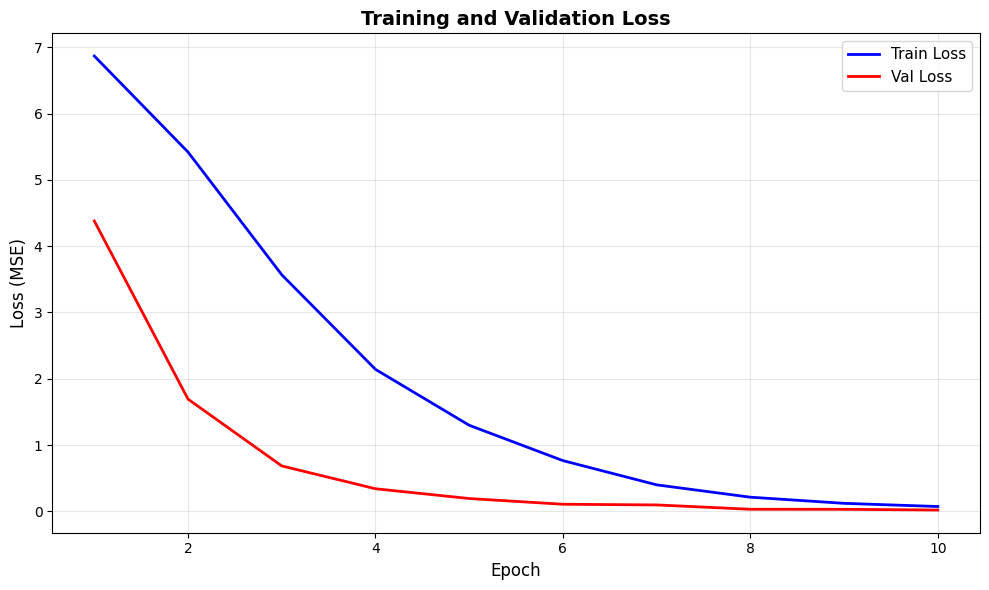

Training curve saved as 'training_curve.png'


In [13]:
# 학습 곡선 시각화
fig, ax = plt.subplots(figsize=(10, 6))

epochs_range = range(1, len(train_losses) + 1)
ax.plot(epochs_range, train_losses, 'b-', label='Train Loss', linewidth=2)
ax.plot(epochs_range, val_losses, 'r-', label='Val Loss', linewidth=2)

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss (MSE)', fontsize=12)
ax.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curve.png', dpi=150)
plt.show()

print("Training curve saved as 'training_curve.png'")

In [14]:
# 테스트 데이터 평가
print("Evaluating on test set...")
model.eval()

test_loss = 0.0
all_predictions = []
all_targets = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Testing'):
        toaPos_batch = batch['toaPos']
        realPos_batch = batch['realPos']
        
        # Prediction
        pred = model(toaPos_batch)
        
        # Loss
        loss = criterion(pred, realPos_batch)
        test_loss += loss.item()
        
        # 결과 저장
        all_predictions.append(pred.cpu())
        all_targets.append(realPos_batch.cpu())

test_loss /= len(test_loader)
print(f"\nTest Loss (MSE): {test_loss:.6f}")
print(f"Test RMSE: {math.sqrt(test_loss):.6f}")

# 결과 합치기
all_predictions = torch.cat(all_predictions, dim=0)  # (num_test_samples, seq_len, 2)
all_targets = torch.cat(all_targets, dim=0)

Evaluating on test set...


Testing: 100%|██████████| 235/235 [00:00<00:00, 341.10it/s]


Test Loss (MSE): 0.019816
Test RMSE: 0.140769


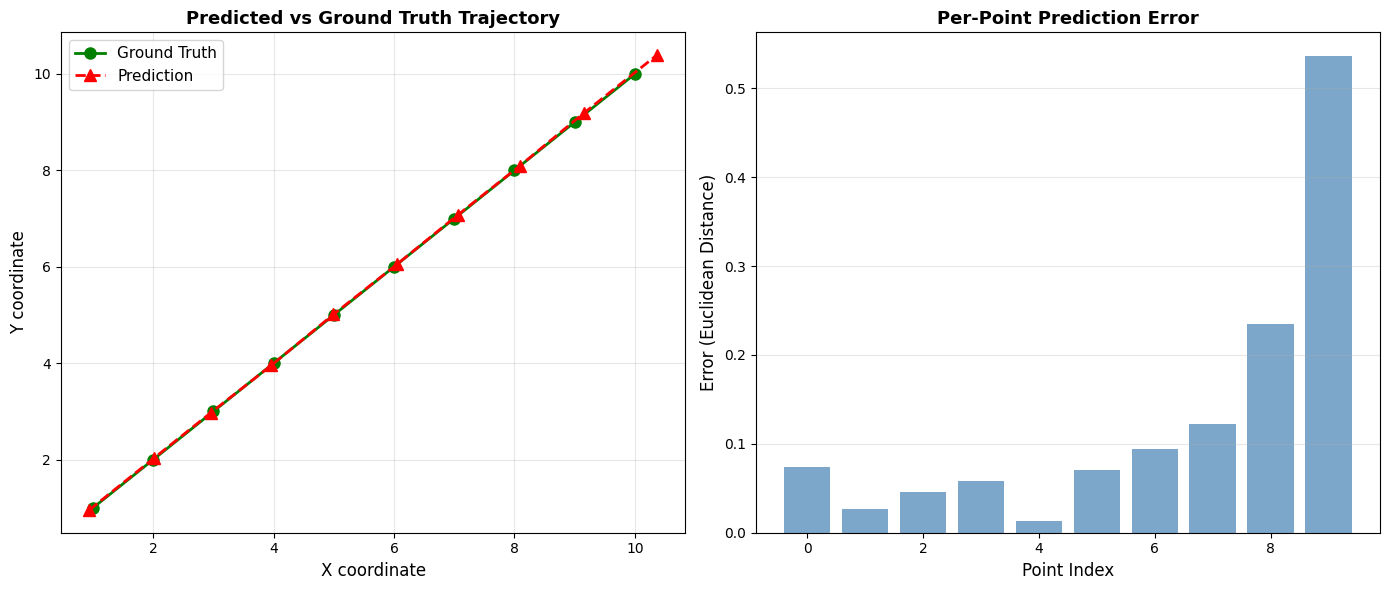


Sample 0 statistics:
  Mean error: 0.127835
  Max error: 0.536105
  Min error: 0.013639

Visualization saved as 'prediction_visualization.png'


In [15]:
# 예측 결과 시각화 (첫 번째 샘플)
sample_idx = 0
pred_seq = all_predictions[sample_idx].numpy()  # (seq_len, 2)
target_seq = all_targets[sample_idx].numpy()    # (seq_len, 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 예측 vs 실제 궤적
axes[0].plot(target_seq[:, 0], target_seq[:, 1], 'go-', 
             label='Ground Truth', linewidth=2, markersize=8)
axes[0].plot(pred_seq[:, 0], pred_seq[:, 1], 'r^--', 
             label='Prediction', linewidth=2, markersize=8)
axes[0].set_xlabel('X coordinate', fontsize=12)
axes[0].set_ylabel('Y coordinate', fontsize=12)
axes[0].set_title('Predicted vs Ground Truth Trajectory', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# 포인트별 오차
errors = np.linalg.norm(pred_seq - target_seq, axis=1)
axes[1].bar(range(len(errors)), errors, color='steelblue', alpha=0.7)
axes[1].set_xlabel('Point Index', fontsize=12)
axes[1].set_ylabel('Error (Euclidean Distance)', fontsize=12)
axes[1].set_title('Per-Point Prediction Error', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('prediction_visualization.png', dpi=150)
plt.show()

print(f"\nSample {sample_idx} statistics:")
print(f"  Mean error: {errors.mean():.6f}")
print(f"  Max error: {errors.max():.6f}")
print(f"  Min error: {errors.min():.6f}")
print("\nVisualization saved as 'prediction_visualization.png'")

Test Set Statistics:
Overall mean error: 0.128195
Overall std error: 0.152313

Mean error per point:
  Point 0: 0.069816
  Point 1: 0.025717
  Point 2: 0.033440
  Point 3: 0.028972
  Point 4: 0.038037
  Point 5: 0.070950
  Point 6: 0.086278
  Point 7: 0.140980
  Point 8: 0.262414
  Point 9: 0.525347


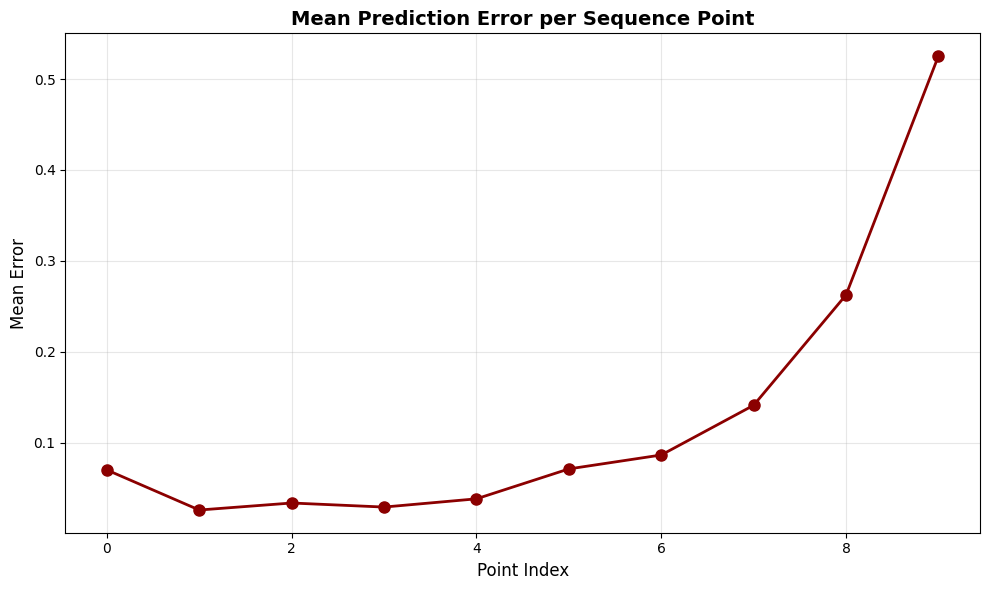


Mean error plot saved as 'mean_error_per_point.png'


In [16]:
# 전체 테스트 셋 통계
all_errors = torch.norm(all_predictions - all_targets, dim=-1)  # (num_samples, seq_len)
mean_errors_per_point = all_errors.mean(dim=0).numpy()  # (seq_len,)
overall_mean_error = all_errors.mean().item()

print("Test Set Statistics:")
print("="*60)
print(f"Overall mean error: {overall_mean_error:.6f}")
print(f"Overall std error: {all_errors.std().item():.6f}")
print(f"\nMean error per point:")
for i, err in enumerate(mean_errors_per_point):
    print(f"  Point {i}: {err:.6f}")

# 포인트별 평균 오차 시각화
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(len(mean_errors_per_point)), mean_errors_per_point, 
        'o-', linewidth=2, markersize=8, color='darkred')
ax.set_xlabel('Point Index', fontsize=12)
ax.set_ylabel('Mean Error', fontsize=12)
ax.set_title('Mean Prediction Error per Sequence Point', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('mean_error_per_point.png', dpi=150)
plt.show()

print("\nMean error plot saved as 'mean_error_per_point.png'")

In [17]:
# 학습 요약
print("="*60)
print("TRAINING SUMMARY")
print("="*60)
print(f"\nConfiguration:")
print(f"  Noise variance level: {config['noise_idx']}")
print(f"  Batch size: {config['batch_size']}")
print(f"  Epochs: {config['num_epochs']}")
print(f"  Learning rate: {config['learning_rate']}")
print(f"  Model d_model: {config['d_model']}")
print(f"  Model heads: {config['nhead']}")
print(f"  Model layers: {config['num_layers']}")
print(f"\nData:")
print(f"  Sequence length: {full_dataset.seq_len}")
print(f"  Train samples: {train_size}")
print(f"  Val samples: {val_size}")
print(f"  Test samples: {test_size}")
print(f"\nResults:")
print(f"  Best validation loss: {best_val_loss:.6f}")
print(f"  Test loss (MSE): {test_loss:.6f}")
print(f"  Test RMSE: {math.sqrt(test_loss):.6f}")
print(f"  Mean prediction error: {overall_mean_error:.6f}")
print(f"\nModel saved as: best_transformer_model.pth")
print("="*60)

TRAINING SUMMARY

Configuration:
  Noise variance level: 4
  Batch size: 64
  Epochs: 10
  Learning rate: 0.0001
  Model d_model: 128
  Model heads: 8
  Model layers: 4

Data:
  Sequence length: 10
  Train samples: 70000
  Val samples: 15000
  Test samples: 15000

Results:
  Best validation loss: 0.019837
  Test loss (MSE): 0.019816
  Test RMSE: 0.140769
  Mean prediction error: 0.128195

Model saved as: best_transformer_model.pth
